In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
try:
    titanic_data = pd.read_csv("/content/titanic_dataset.csv")
except FileNotFoundError:
    print("Local dataset not found. Loading from public repository instead...")
    titanic_data = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

titanic_data.head()

Local dataset not found. Loading from public repository instead...


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
from typing import dataclass_transform
titanic_data.info()

Missing values

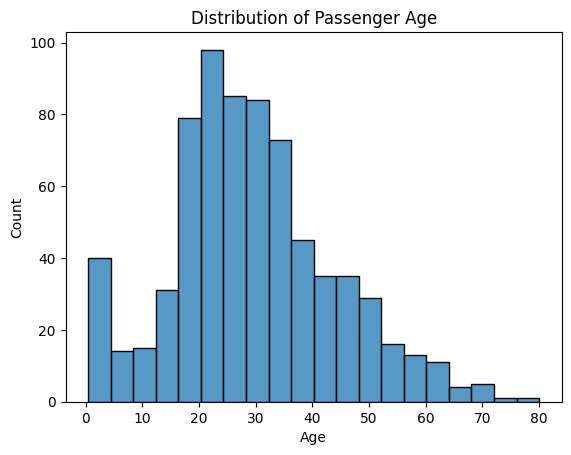

In [10]:
sns.histplot(titanic_data['Age'])
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [11]:
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median())


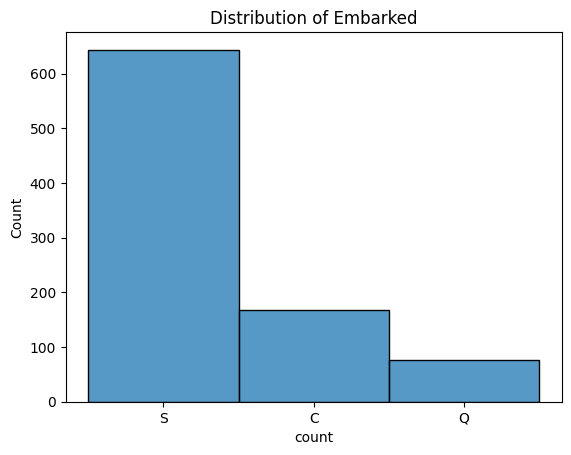

In [12]:
sns.histplot(titanic_data['Embarked'])
plt.title('Distribution of Embarked')
plt.xlabel('count')
plt.ylabel('Count')
plt.show()

In [13]:
titanic_data.drop(columns=['Cabin'], inplace=True, errors='ignore')

In [14]:
most_frequent_embarked = titanic_data['Embarked'].mode()[0]
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(most_frequent_embarked)


In [15]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


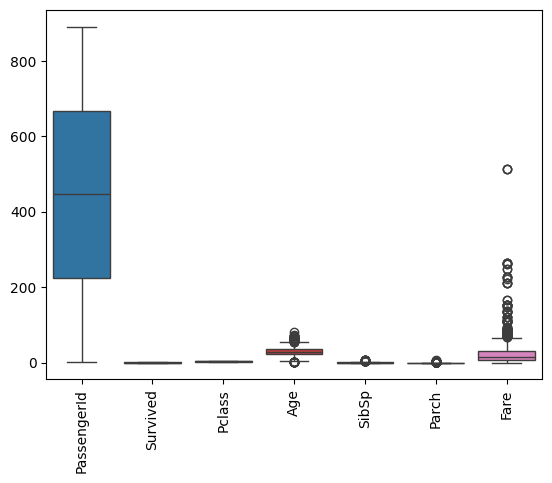

In [16]:
sns.boxplot(titanic_data)
plt.xticks(rotation=90)
plt.show()

Outlier

6. Check and handle outliers in at least 3 columns in the dataset

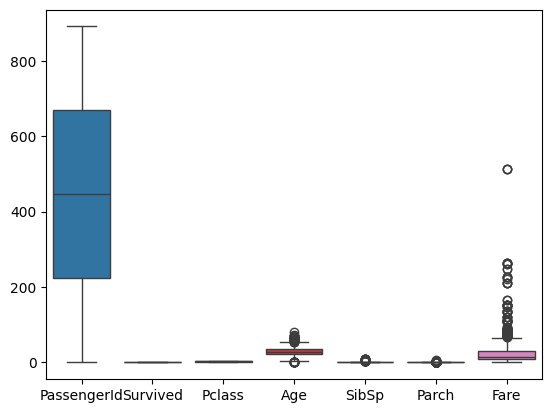

In [17]:
sns.boxplot(titanic_data)
plt.show()

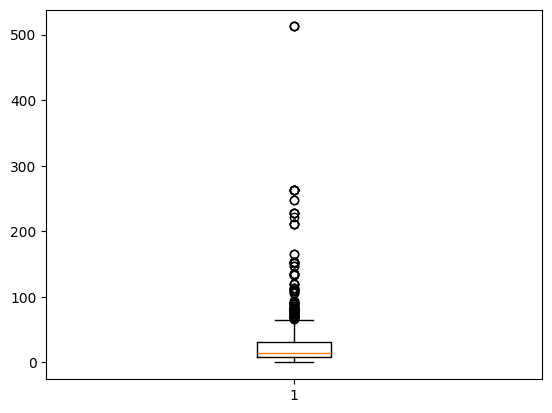

In [18]:
plt.boxplot(titanic_data['Fare'])
plt.show()

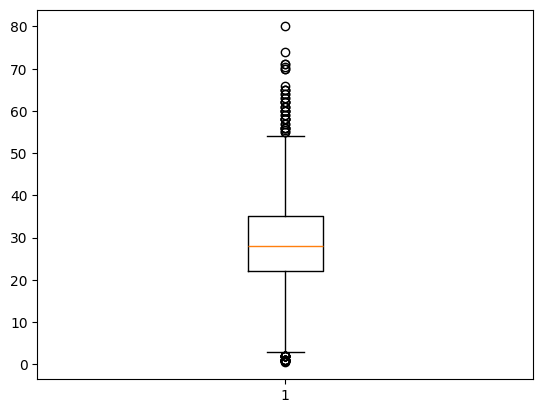

In [19]:
plt.boxplot(titanic_data['Age'])
plt.show()

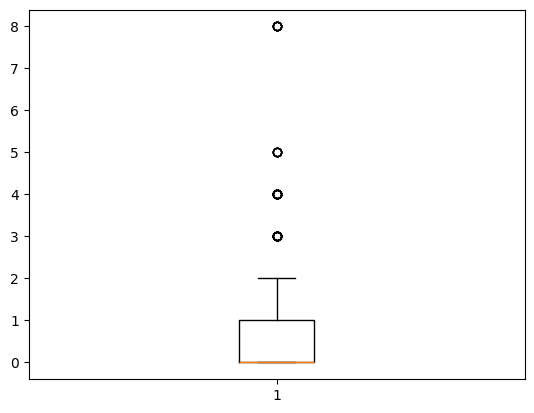

In [20]:
plt.boxplot(titanic_data['SibSp'])
plt.show()

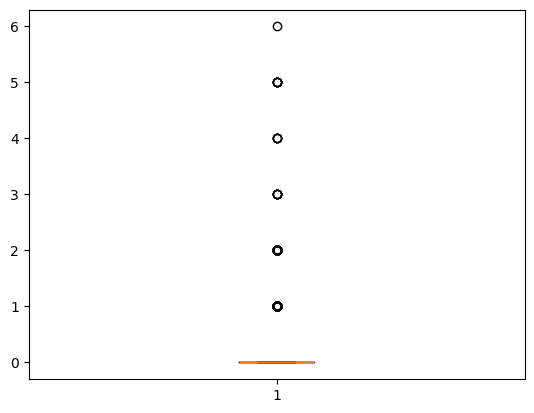

In [21]:
plt.boxplot(titanic_data['Parch'])
plt.show()

remove outliers---->Parch and Sibsp,
clipping outliers age and fare colunms.

IQR method

In [23]:
q1 = titanic_data['Parch'].quantile(0.25)
q2 = titanic_data['Parch'].quantile(0.5)
q3 = titanic_data['Parch'].quantile(0.75)


print(f'Q1 = {q1}\nQ2={q2}\nQ3={q3}')

iqr = q3-q1
up_limt =q3+(1.5*iqr)
low_limt =q1- (1.5*iqr)
print(f'IQR ={iqr}\nup_limt ={up_limt}\nlow_limt ={low_limt}')

Q1 = 0.0
Q2=0.0
Q3=0.0
IQR =0.0
up_limt =0.0
low_limt =0.0


In [24]:
titanic_data.nunique().sum()

np.int64(2823)

age colunm cliping

In [25]:
q1 = titanic_data['Age'].quantile(0.25)
q2 = titanic_data['Age'].quantile(0.5)
q3 = titanic_data['Age'].quantile(0.75)


print(f'Q1 = {q1}\nQ2={q2}\nQ3={q3}')

iqr = q3-q1
up_limt =q3+(1.5*iqr)
low_limt =q1- (1.5*iqr)
print(f'IQR ={iqr}\nup_limt ={up_limt}\nlow_limt ={low_limt}')

Q1 = 22.0
Q2=28.0
Q3=35.0
IQR =13.0
up_limt =54.5
low_limt =2.5


In [26]:
titanic_data.loc[titanic_data['Age'] > up_limt, 'Age'] = up_limt
titanic_data.loc[titanic_data['Age'] < low_limt, 'Age'] = low_limt

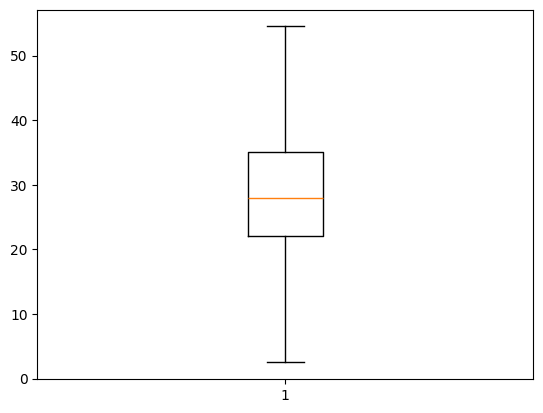

In [27]:
plt.boxplot(titanic_data['Age'])
plt.show()

In [28]:
q1 = titanic_data['Fare'].quantile(0.25)
q2 = titanic_data['Fare'].quantile(0.5)
q3 = titanic_data['Fare'].quantile(0.75)


print(f'Q1 = {q1}\nQ2={q2}\nQ3={q3}')

iqr = q3-q1
up_limt =q3+(1.5*iqr)
low_limt =q1- (1.5*iqr)
print(f'IQR ={iqr}\nup_limt ={up_limt}\nlow_limt ={low_limt}')

Q1 = 7.9104
Q2=14.4542
Q3=31.0
IQR =23.0896
up_limt =65.6344
low_limt =-26.724


In [29]:
titanic_data.loc[titanic_data['Fare'] > up_limt, 'Fare'] = up_limt
titanic_data.loc[titanic_data['Fare'] < low_limt, 'Fare'] = low_limt

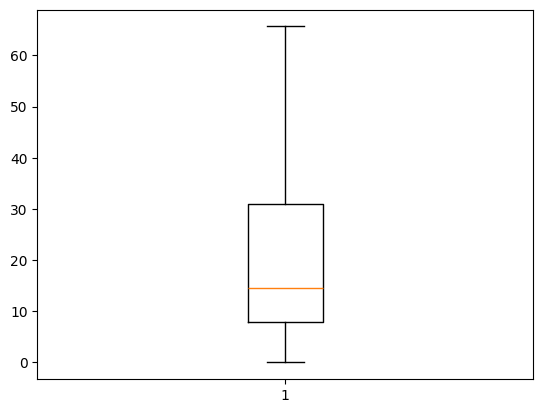

In [30]:
plt.boxplot(titanic_data['Fare'])
plt.show()

Encoding

In [31]:
titanic_data.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [32]:
## encoding categorical colunms
## categorical colunms are ---->Sex and Embarked

In [33]:
titanic_data['Sex'].unique()

array(['male', 'female'], dtype=object)

In [34]:
## one-hot encoding
titanic_data = pd.get_dummies(titanic_data,dtype='int',drop_first=True)
titanic_data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,1,38.0,1,0,65.6344,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0,3,35.0,0,0,8.0500,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,0,0,0,...,0,0,0,0,0,0,0,0,0,1
887,888,1,1,19.0,0,0,30.0000,0,0,0,...,0,0,0,0,0,0,0,0,0,1
888,889,0,3,28.0,1,2,23.4500,0,0,0,...,0,0,1,0,0,0,0,0,0,1
889,890,1,1,26.0,0,0,30.0000,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Spliting feature and target colunms

In [35]:
x = titanic_data.drop(['Survived'],axis=1) ##feature and target
y = titanic_data['Survived']

In [36]:
x

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,38.0,1,0,65.6344,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,3,26.0,0,0,7.9250,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,35.0,1,0,53.1000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,3,35.0,0,0,8.0500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,27.0,0,0,13.0000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
887,888,1,19.0,0,0,30.0000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
888,889,3,28.0,1,2,23.4500,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
889,890,1,26.0,0,0,30.0000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


Train Test Spliting

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2, random_state= 42,stratify=y
)

In [39]:
x_train

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
692,693,3,28.0,0,0,56.4958,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
481,482,2,28.0,0,0,0.0000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
527,528,1,28.0,0,0,65.6344,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
855,856,3,18.0,0,1,9.3500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
801,802,2,31.0,1,1,26.2500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,360,3,28.0,0,0,7.8792,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
258,259,1,35.0,0,0,65.6344,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
736,737,3,48.0,1,3,34.3750,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
462,463,1,47.0,0,0,38.5000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [40]:
y_train

,Survived
692,1
481,0
527,0
855,1
801,1
...,...
359,1
258,1
736,0
462,0


In [41]:
x_test

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
565,566,3,24.0,2,0,24.1500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
160,161,3,44.0,0,1,16.1000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
553,554,3,22.0,0,0,7.2250,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,861,3,41.0,2,0,14.1083,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
241,242,3,28.0,1,0,15.5000,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,2,25.0,0,1,26.0000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
91,92,3,20.0,0,0,7.8542,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
883,884,2,28.0,0,0,10.5000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
473,474,2,23.0,0,0,13.7917,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
y_test

,Survived
565,0
160,0
553,1
860,0
241,1
...,...
880,1
91,0
883,0
473,1


In [ ]:
#Feature Scalling/ Scaling

In [43]:
# creating a copy of my features
x1=x.copy()
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
for i in ['Age','Fare']:
  x1[i] = scaler.fit_transform(x1[[i]])
  x1.describe()


In [44]:
# scaled x_train1 and x_test1
from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
# non scaled x_train and x_test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
x_train.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
692,693,3,28.0,0,0,56.4958,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
481,482,2,28.0,0,0,0.0000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
527,528,1,28.0,0,0,65.6344,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
855,856,3,18.0,0,1,9.3500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
801,802,2,31.0,1,1,26.2500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [47]:
x_train1.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
692,693,3,0.490385,0,0,0.860765,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
481,482,2,0.490385,0,0,0.000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
527,528,1,0.490385,0,0,1.000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
855,856,3,0.298077,0,1,0.142456,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
801,802,2,0.548077,1,1,0.399943,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [48]:
x_train1.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
692,693,3,0.490385,0,0,0.860765,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
481,482,2,0.490385,0,0,0.000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
527,528,1,0.490385,0,0,1.000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
855,856,3,0.298077,0,1,0.142456,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
801,802,2,0.548077,1,1,0.399943,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [49]:
x_test1.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
565,566,3,0.413462,2,0,0.367947,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
160,161,3,0.798077,0,1,0.245298,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
553,554,3,0.375000,0,0,0.110079,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,861,3,0.740385,2,0,0.214953,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
241,242,3,0.490385,1,0,0.236157,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
#ML Model

In [50]:
#7.Try out all the classification models discussed and find out which one is the best

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
lr_model =LogisticRegression(max_iter=1000)
lr_model.fit(x_train1,y_train)
y_pred_lr_model = lr_model.predict(x_test1)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,f1_score,recall_score
print(confusion_matrix(y_test,y_pred_lr_model))
print('Accuracy is: ',accuracy_score(y_test,y_pred_lr_model))
print('Precision is: ',precision_score(y_test,y_pred_lr_model))
print('Recall is: ',recall_score(y_test,y_pred_lr_model))
print('F1 score is: ',f1_score(y_test,y_pred_lr_model))

[[99 11]
 [23 46]]
Accuracy is:  0.8100558659217877
Precision is:  0.8070175438596491
Recall is:  0.6666666666666666
F1 score is:  0.7301587301587301


KNN

In [54]:
#KNN
# Finding the optimum k value
from sklearn.neighbors import KNeighborsClassifier

acc_score =[]
for i in range(3,10):
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(x_train1,y_train)
  y_pred_knn = knn.predict(x_test1)
  acc = accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

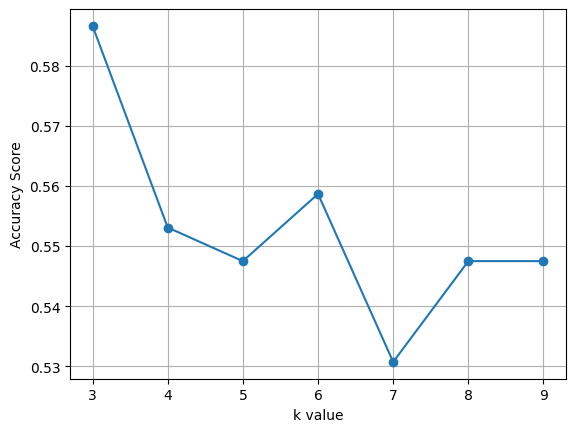

In [55]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.xlabel('k value')
plt.ylabel('Accuracy Score')
plt.grid()

In [56]:
# optimum k values value is 4 because accuracy is high when k =4
# train the knn model k=4
knn= KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train1,y_train)
y_pred_knn = knn.predict(x_test1)
print(confusion_matrix(y_test,y_pred_knn))
print('Accuracy is : ',accuracy_score(y_test,y_pred_knn))
print('Precision is : ',precision_score(y_test,y_pred_knn))
print('Recall is : ',recall_score(y_test,y_pred_knn))
print('F1 score is : ',f1_score(y_test,y_pred_knn))

[[89 21]
 [59 10]]
Accuracy is :  0.553072625698324
Precision is :  0.3225806451612903
Recall is :  0.14492753623188406
F1 score is :  0.2


SVM

In [57]:
from sklearn.svm import SVC

In [59]:
#linear kernal
svm_linear =SVC(kernel ='linear')
svm_linear.fit(x_train1,y_train)
y_pred_svm_linear = svm_linear.predict(x_test1)
print(confusion_matrix(y_test,y_pred_svm_linear))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_linear))
print('Precision is : ',precision_score(y_test,y_pred_svm_linear))
print('Recall is : ',recall_score(y_test,y_pred_svm_linear))
print('F1 score is : ',f1_score(y_test,y_pred_svm_linear))

Polinomiyal

In [60]:
## polinomial

svm_poly =SVC(kernel ='poly')
svm_poly.fit(x_train1,y_train)
y_pred_svm_poly = svm_poly.predict(x_test1)
print(confusion_matrix(y_test,y_pred_svm_poly))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_poly))
print('Precision is : ',precision_score(y_test,y_pred_svm_poly))
print('Recall is : ',recall_score(y_test,y_pred_svm_poly))
print('F1 score is : ',f1_score(y_test,y_pred_svm_poly))

[[110   0]
 [ 69   0]]
Accuracy is :  0.6145251396648045
Precision is :  0.0
Recall is :  0.0
F1 score is :  0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RBF

In [61]:

##RBF'
svm_rbf =SVC(kernel ='rbf')
svm_rbf.fit(x_train1,y_train)
y_pred_svm_rbf = svm_rbf.predict(x_test1)
print(confusion_matrix(y_test,y_pred_svm_rbf))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_rbf))
print('Precision is : ',precision_score(y_test,y_pred_svm_rbf))
print('Recall is : ',recall_score(y_test,y_pred_svm_rbf))
print('F1 score is : ',f1_score(y_test,y_pred_svm_rbf))

[[110   0]
 [ 69   0]]
Accuracy is :  0.6145251396648045
Precision is :  0.0
Recall is :  0.0
F1 score is :  0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Decision Tree

In [62]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion= 'entropy',random_state=42)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(confusion_matrix(y_test,y_pred_dt))
print('Accuracy is : ',accuracy_score(y_test,y_pred_dt))
print('Precision is : ',precision_score(y_test,y_pred_dt))
print('Recall is : ',recall_score(y_test,y_pred_dt))
print('F1 score is : ',f1_score(y_test,y_pred_dt))

[[86 24]
 [19 50]]
Accuracy is :  0.7597765363128491
Precision is :  0.6756756756756757
Recall is :  0.7246376811594203
F1 score is :  0.6993006993006993


Random Forest

In [63]:
#Random forest

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='entropy',random_state = 42)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print(confusion_matrix(y_test,y_pred_rf))
print('Accuracy is : ',accuracy_score(y_test,y_pred_rf))
print('Precision is : ',precision_score(y_test,y_pred_rf))
print('Recall is : ',recall_score(y_test,y_pred_rf))
print('F1 score is : ',f1_score(y_test,y_pred_rf))

[[102   8]
 [ 27  42]]
Accuracy is :  0.8044692737430168
Precision is :  0.84
Recall is :  0.6086956521739131
F1 score is :  0.7058823529411765


best Accuracy ---->Logistic regression,81